In [274]:
import xarray as xr
import numpy as np
import geopandas as gpd
import cartopy.io.shapereader as shpreader
from shapely.geometry import box
import shapely.vectorized as sv
import matplotlib.pyplot as plt
import pandas as pd

In [275]:
def average_capacity_factors(filename):
    '''
    Function to read in a .nc file and calculate the average capacity factors over time.
    '''
    ds = xr.open_dataset(filename)

    cf_avg = ds.mean(dim='time')

    return cf_avg

def get_top_60_percent_cfs(avg_capacity_factors):
    '''
    Function to get the top 60% of capacity factors.
    '''
    cfs_60 = avg_capacity_factors.where(avg_capacity_factors > avg_capacity_factors.quantile(0.01), -1)

    # Assuming 'variable_name' is the name of the variable in the Dataset
    num_cfs_60 = cfs_60['capacity factor'].where(cfs_60['capacity factor'] != -1).notnull().sum().item()
    print(f"Number of grid cells in the top 60%: {num_cfs_60}/{cfs_60['capacity factor'].size}")

    return cfs_60

In [276]:
def get_time_series_top_60_percent_cfs(filename, cfs_60, cf_type):
    '''
    Function to get the time series of the top 60% of capacity factors.
    '''
    ds = xr.open_dataset(filename)

    # Save average over all grid cells to csv file
    ds_avg = ds.mean(dim=['x', 'y'])
    ds_avg_df = ds_avg.to_dataframe()
    ds_avg_df = ds_avg_df.rename(columns={'capacity factor': f'{cf_type}_cf_avg'})
    year = filename.split('_')[-1].split('.')[0]
    # ds_avg_df.to_csv(f'CONUS_{cf_type}_CF_avg_all_{year}.csv')

    # Get time series of top 60% grid cells
    cfs_60_ts = ds.where(cfs_60 > 0)

    # Average over all grid cells
    cfs_60_ts = cfs_60_ts.mean(dim=['x', 'y'])

    # Write to csv file
    cfs_60_df = cfs_60_ts.to_dataframe()

    # Drop columns execpt for time and capacity factor
    cfs_60_df = cfs_60_df.drop(columns=['quantile'])
    # Rename columns
    cfs_60_df = cfs_60_df.rename(columns={'capacity factor': f'{cf_type}_cf'})
    
    # Write to csv file
    year = filename.split('_')[-1].split('.')[0]
    cfs_60_df.to_csv(f'CONUS_{cf_type}_CF_{year}.csv')

In [ ]:
def plot_capacity_factor(cf, cap_fac_type):
    from shapely.validation import make_valid

    miso = gpd.read_file("/Users/mshaaban/clab_underground_th_storage/data_folder/wind_solar_capacity_factors_MISO/miso_shapefile.geojson")
    if miso.crs is None or miso.crs.to_epsg() != 4326:
        miso = miso.to_crs(epsg=4326)
    #miso_geom = miso.geometry.union_all()

        # Fix invalid geometries
    miso["geometry"] = miso["geometry"].apply(make_valid)
    miso_geom = miso.geometry.union_all()

    lon, lat = np.meshgrid(cf['x'], cf['y'])
    mask = sv.contains(miso_geom, lon, lat)
    masked_dataset = cf.where(mask)

    aspect_ratio = (cf['x'].max()-cf['x'].min())/(cf['y'].max()-cf['y'].min())
    masked_dataset["capacity factor"].plot(aspect=aspect_ratio, size=5, vmin=0.)
    plt.title(f'{cap_fac_type} MISO average')
    plt.savefig(f'capacity_factor_MISO_{cap_fac_type.replace(" ","").replace("%","")}.jpg')
    print(masked_dataset["capacity factor"].where(masked_dataset["capacity factor"] > 0).mean().values)

In [278]:
def get_60_percent_cf_all(cf_type):
    """
    Get the top 60% capacity factors for all years
    """

    cf_avg_2020 = average_capacity_factors(f'miso_{cf_type}_CF_timeseries_2020.nc')
    cf_avg_2021 = average_capacity_factors(f'miso_{cf_type}_CF_timeseries_2021.nc')
    cf_avg_2022 = average_capacity_factors(f'miso_{cf_type}_CF_timeseries_2022.nc')
    cf_avg_2024 = average_capacity_factors(f'miso_{cf_type}_CF_timeseries_2024.nc')
    cf_avg_2023 = average_capacity_factors(f'miso_{cf_type}_CF_timeseries_2023.nc')

    cf_avg_all = (cf_avg_2020 + cf_avg_2021 + cf_avg_2022 + cf_avg_2023 + cf_avg_2024)/5

    # Plot 
    plot_capacity_factor(cf_avg_all, cf_type)
    cf_all_60 = get_top_60_percent_cfs(cf_avg_all)
    plot_capacity_factor(cf_all_60, cf_type+" top 60%")

    cfs = []
    for year in range(2020, 2025):

        cf_ts = xr.open_dataset(f'miso_{cf_type}_CF_timeseries_{year}.nc')

        # Only keep the capacity factors that are non-zero in cf_all_60
        cf_ts = cf_ts.where(cf_all_60 > -1)

        # Average over all grid cells
        cf_ts = cf_ts.mean(dim=['x', 'y'])

        cfs.append(cf_ts)

    cf_ts_all = xr.concat(cfs, dim='time')
    # Drop quantile dimension
    cf_ts_all = cf_ts_all.drop('quantile')
    # Rename capacity factor dimension
    cf_ts_all = cf_ts_all.rename({'capacity factor': f'{cf_type}_cf'})
    # Write to csv file
    cf_ts_all_df = cf_ts_all.to_dataframe()
    cf_ts_all_df.to_csv(f'MISO_{cf_type}_CF_2020_2024.csv')


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/4294258420.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.20732103976514107
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/4294258420.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.20732103976514107


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/2137539091.py:34: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  cf_ts_all = cf_ts_all.drop('quantile')
/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/4294258420.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.22625344065094805
Number of grid cells in the top 60%: 7918/7998


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/4294258420.py:14: DeprecationWarning: The 'shapely.vectorized.contains' function is deprecated and will be removed a future version. Use 'shapely.contains_xy' instead (available since shapely 2.0.0).
  mask = sv.contains(miso_geom, lon, lat)


0.22625344065094805


/var/folders/fs/wbkdjscx14xgrf3swy5zjlgsv7jf9p/T/ipykernel_39423/2137539091.py:34: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  cf_ts_all = cf_ts_all.drop('quantile')


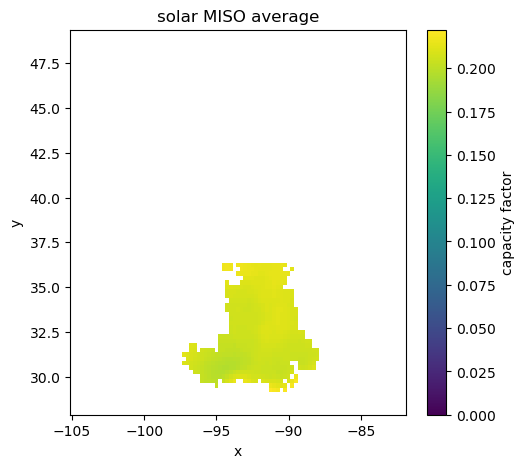

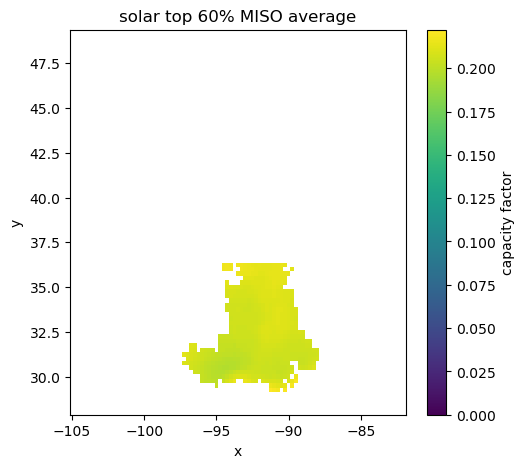

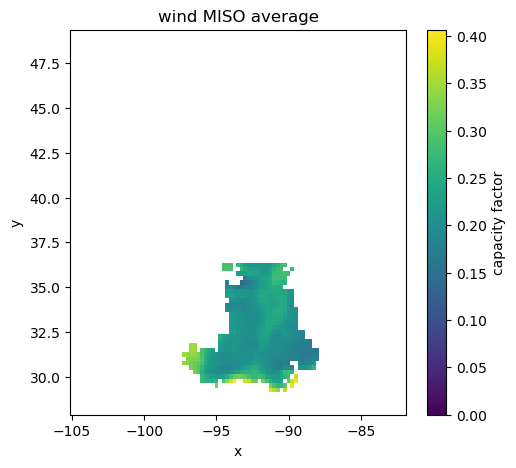

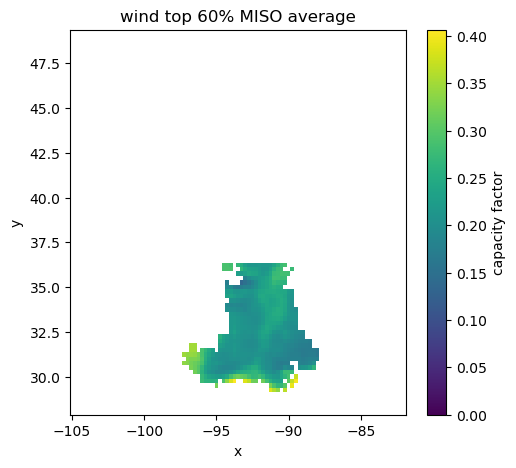

In [279]:
get_60_percent_cf_all('solar')
get_60_percent_cf_all('wind')

In [280]:
def read_csv_file(filename):
    """
    Read csv file
    """
    df = pd.read_csv(filename)
    # Print mean of columm 1
    print(df.iloc[:,1].mean())

# Source for reported capacity factors:
# https://www.eia.gov/electricity/monthly/epm_table_grapher.php?t=table_6_07_b
print("Solar")
print("Reported 5 year average of capacity factors")
print((20.38+22.26+23.03+22.83+21.81)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_solar_CF_2020_2024.csv')

print("\n")
print("Wind")
print("Reported 5 year average of capacity factors")
print((31.66+32.13+36.65+31.76+33.15)/5./100.)
print("Mean capacity factor of top 60% of grid cells")
read_csv_file('MISO_wind_CF_2020_2024.csv')

Solar
Reported 5 year average of capacity factors
0.22062
Mean capacity factor of top 60% of grid cells
0.22075546090601247


Wind
Reported 5 year average of capacity factors
0.3307
Mean capacity factor of top 60% of grid cells
0.35664698415128343
